In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

import scienceplots
plt.style.use(['science'])

# --- Organized modules ---
from utils.io_utils import (
    get_energy, get_energy_pwscf, collect_q_and_vq,
    load_or_compute_E, get_E_all,
    get_variance_for_run, qmc_params_default,
)
from utils.physics import (
    get_gas_params, get_qs, gen_qidx, chi0q, anal_chi02,
    guess_alpha2, FS_correct,
    get_chi_Moroni, get_chi_RPA, get_chi_corradini,
    G_Moroni, corradini_pz,
)
from utils.fitting import (
    get_chi_q, get_chi0_q, get_correction, get_chi,
    bootstrap_chi_error, analyze_vq_range,
    _fit_func, fit_E_of_vq, fit_quality_report,
)
from utils.plotting import plot_chi, plot_E_of_vq, plot_variance


54


/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils.py:76: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(f_new, np.array(vq_list)*alpha, E_list[:])


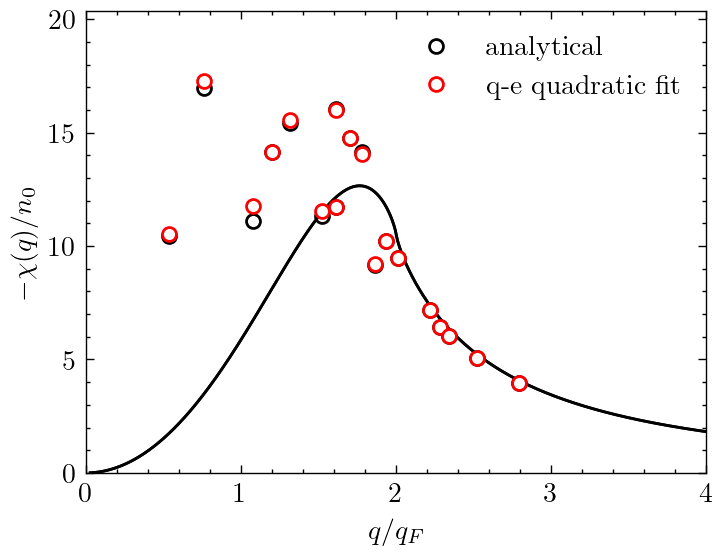

In [ ]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
Ne=54
if Ne==54: n_shell=4
if Ne==162: n_shell=7
if Ne==294: n_shell=10
if Ne==406: n_shell=13

rs=5



fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
chi0_a=anal_chi02(rs,Ne,qidx_list)#np.load('chi0_a.npy')

#vq_list=np.arange(0,0.0008,0.0001)
vq_list = np.arange(0,0.014,0.002)
chi00_q=get_chi0_q(main_dir,Ne,rs,vq_list,qidx_list)[0]

plot_chi(qidx_list,chi0_a,0,rs,Ne,ax=ax,c='k',label='analytical')
plot_chi(qidx_list,chi00_q,0,rs,Ne,ax=ax,c='r',label='q-e quadratic fit')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(list(by_label.values())[::-1], list(by_label.keys())[::-1])
#ax.set_xlim(0,4)
#ax.set_ylim(-.1,300)
ax.legend()

#fig.savefig(f'./Figures/chi0_2e-3_quadratic.pdf', format='pdf', bbox_inches='tight')

E_GS = 0.043
54
54
anal chi = [11.72828755]
dft chi = 10.826820083746982


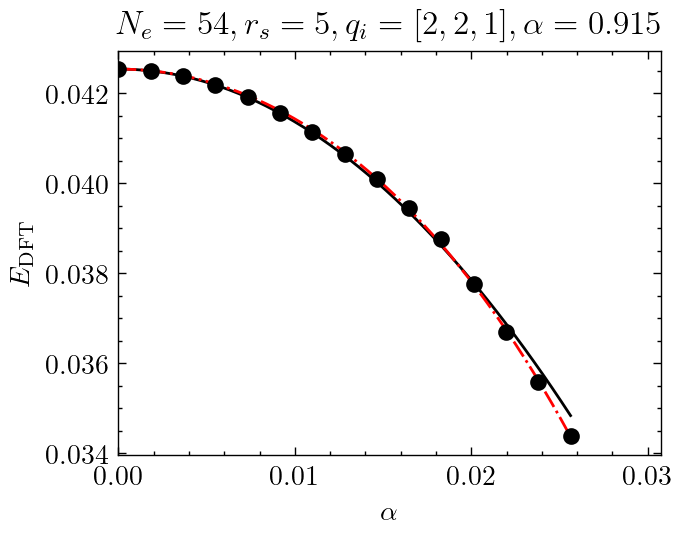

In [71]:
fig, ax = plt.subplots( dpi=200)
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
#main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/threshold_test/runs" #lowq
dft_func='ni'
ecut_pre=125
Ne=54
rs=5

qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
#vq_list=np.arange(0,0.001,0.0001)
iq=7
q=qidx_list[iq]
vq_list=np.arange(0,0.030,0.002)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='r-.',pwscf=True,ax=ax,markersize=5,markeredgecolor='black',markerfacecolor='black',label='E_DFT')


/tmp/ipykernel_3527437/2696991310.py:95: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(quartic, np.array(vql[:]), E_list[:], sigma=dE_list, absolute_sigma=True)


-chi/n0 = 52.140
-chi/n0 = 42.221
-chi/n0 = 33.563
-chi/n0 = 34.635


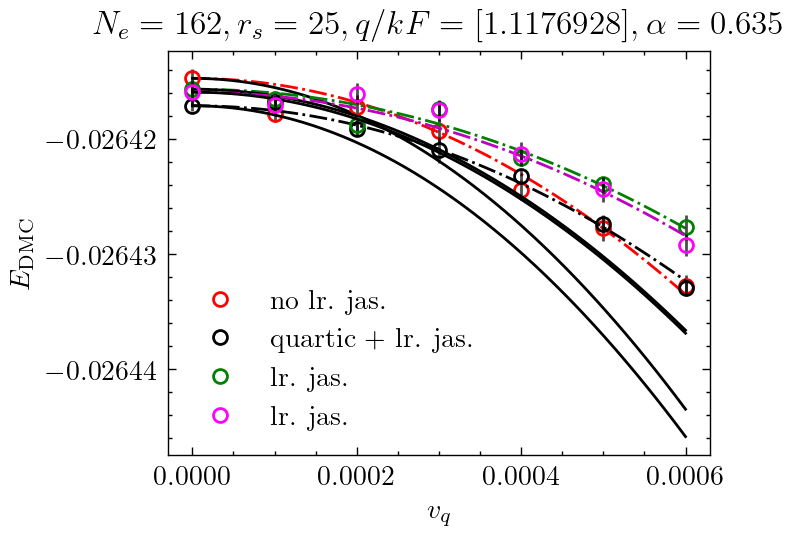

In [153]:
fig, ax = plt.subplots( dpi=200)

#main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/threshold_test/runs" #lowq
dft_func='ni'
ecut_pre=125


iq=11
q=qidx_list[iq]

Ne=162
rs=25
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='r-.',ax=ax,markersize=5,markeredgecolor='red',markerfacecolor='red',label='no lr. jas.')

Ne=162
rs=25
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='k-.',ax=ax,markersize=5,markeredgecolor='black',markerfacecolor='black',label='quartic + lr. jas.')


q=qidx_list[7]
Ne=162
rs=25
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='g-.',ax=ax,markersize=5,markeredgecolor='green',markerfacecolor='green',label='lr. jas.')

q=qidx_list[7]
Ne=162
rs=25
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='m-.',ax=ax,markersize=5,markeredgecolor='magenta',markerfacecolor='magenta',label='lr. jas.')



ax.legend()
#fig.savefig(f'./Figures/E_vq_lr-vs-nolr.pdf', format='pdf', bbox_inches='tight')

In [17]:
vq_list

array([0.    , 0.0002, 0.0004, 0.0006, 0.0008, 0.001 ])

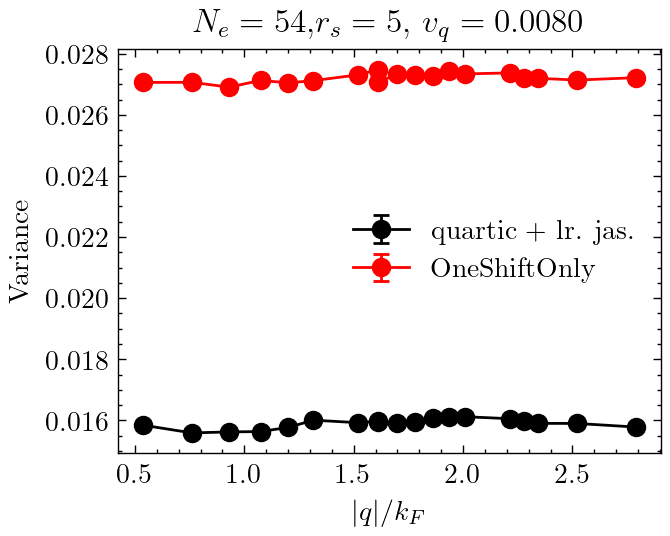

In [ ]:
fig, ax = plt.subplots(dpi=200)
vq_list=np.arange(0,0.001,0.0001)
iq=5
q=qidx_list[iq]
vq=0.008
#for i in range(len(np.arange(0,0.001,0.0001))):
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
ax, x, var, dvar = plot_variance(main_dir, rs=5, Ne=54, ax=ax, color='k',
                                    vq_list=np.arange(0,0.02,0.002),
                                    qidx_list=qidx_list,
                                    vs='q',
                                    fixed_val=vq,label='quartic + lr. jas.')#[2,1,1]

main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/nolr_jastrow_full/runs"
ax, x, var, dvar = plot_variance(main_dir, rs=5, Ne=54, ax=ax, color='r',
                                    vq_list=np.arange(0,0.02,0.002),
                                    qidx_list=qidx_list,
                                    vs='q',
                                    fixed_val=vq,label='OneShiftOnly')#[2,1,1]

ax.legend()



# Get single point variance
#var, dvar = get_variance_for_run(main_dir, rs, Ne, q=[1,0,0], vq=0.001)
fig.savefig(f'./Figures/variance_lr-vs-nolr.pdf', format='pdf', bbox_inches='tight')

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs5.0-n54.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 19 q × 15 vq → ./output/E_all_rs5.0-n54.npz
Fitting E(vq) for 18 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------
[2, 2, 2]


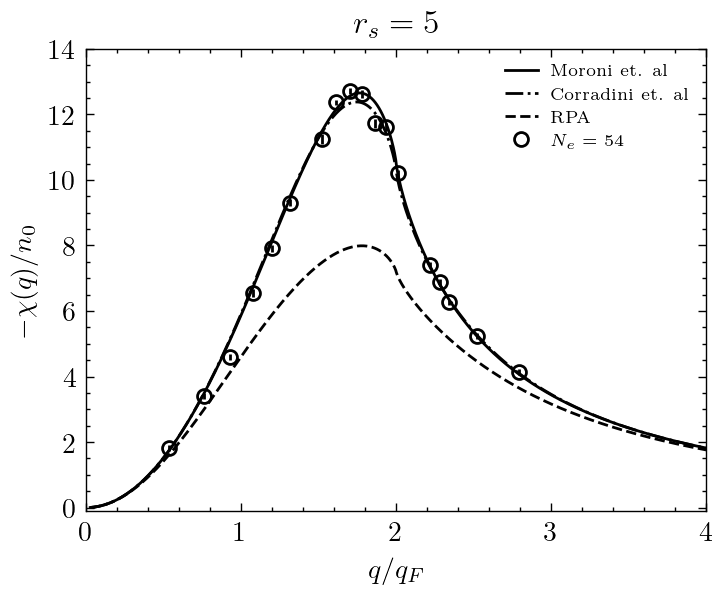

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/nolr_jastrow_full/runs"
vq_common = np.arange(0,0.012,0.004)
qidx_list54 = [[1, 0, 0],
 [1, 1, 0],
 [1, 1, 1],
 [2, 0, 0],
 [2, 1, 0],
 [2, 1, 1],
 [3, 2, 0],
 [3, 2, 1],
 [3, 2, 2],
 [3, 3, 0],
 [3, 3, 1],
 [3, 3, 2],
 [3, 3, 3]]

rs=5
ecut_pre=125
fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

#lr_jastrow
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
Ne=54
qidx_list, vq_list = collect_q_and_vq(main_dir,5,Ne)
vq_list = vq_common #np.arange(0,0.014,0.002)
#qidx_list = qidx_list54
qidx_list.remove([2,2,1])
chi, dchi, fq = get_chi(main_dir, vq_list[:],qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

#ax.set_xlim(0,1)
ax.set_ylim(-.1,14)
#ax.legend()
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
#ax.legend(by_label.values()[], by_label.keys())
ax.legend(list(by_label.values())[::1], list(by_label.keys())[::1],fontsize=6)

indices=[7]
print(qidx_list[7])
kF,n0,NF,L=get_gas_params(rs,Ne)
q_selected = get_qs([qidx_list[i] for i in indices],Ne,rs)/kF
#ax.scatter(q_selected, -chi[indices]/n0,s=50)

ax.set_title(rf"$r_s={rs}$")


fig.show()

#fig.savefig(f'./Figures/chi_rs5.pdf', format='pdf', bbox_inches='tight')

In [114]:
get_qs([qidx_list[7]],Ne,rs)/kF

array([1.86136798])

In [75]:
collect_q_and_vq(main_dir,20,162)[1]

[0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009]

In [43]:
data = np.load("E_matrix.npz")

data['vqlist']

array([0.    , 0.0002, 0.0004, 0.0006, 0.0008, 0.001 ])

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs15.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 13 vq → ./output/E_all_rs15.0-n162.npz
Fitting E(vq) for 30 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[1, 0, 0]  chi/n0=-3.4607e+00  SNR=3.6  |A|/dA=3.7  chi2r=0.69  [UNRELIABLE]
  q=[1, 1, 0]  chi/n0=-4.1743e+00  SNR=4.2  |A|/dA=3.8  chi2r=0.67  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [1 0 0].
Fitted with quadratic function by following vq points: [0.     0.0002 0.0004 0.0006 0.0008 0.001 ].
Reason: Low signal-to-noise ratio. SNR = 3.60
-----------------------------------------
q = [1 1 0].
Fitted with quadratic function by following vq points: [0.     0.0002 0.0004 0.0006 0.0008 0.001 ].
Reason: Low signal-to-noise ratio. SNR = 4.21
-----------------------------------------


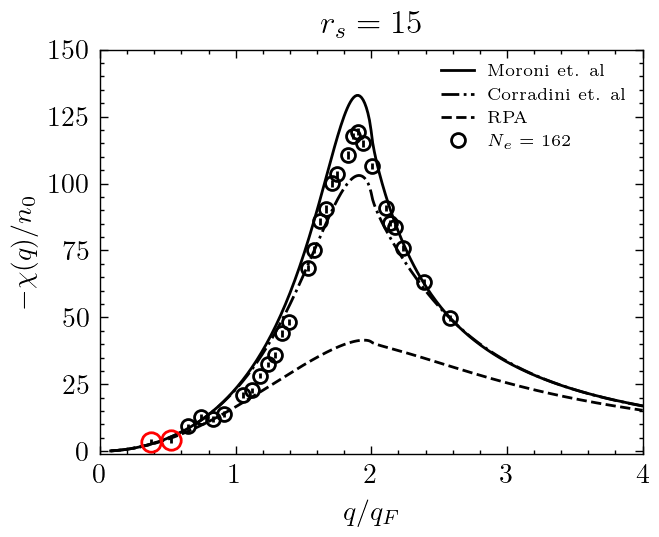

In [29]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"

rs=15
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)
qidx_list.remove([4,0,0])
vq_list=[0,0.0002,0.0004,0.0006,0.0008,0.001]#np.arange(0,0.003,0.001)

chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
#ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)


#ax.set_xlim(0,2)
#ax.set_ylim(-0.5,50)
ax.set_ylim(-1,150)
ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

#plt.savefig(f'./Figures/chi_rs15.pdf', format='pdf', bbox_inches='tight')

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs20.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 10 vq → ./output/E_all_rs20.0-n162.npz
Fitting E(vq) for 30 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[1, 0, 0]  chi/n0=-1.9657e+00  SNR=3.0  |A|/dA=2.1  chi2r=1.38  [UNRELIABLE]
  q=[3, 3, 2]  chi/n0=-1.4474e+02  SNR=132.5  |A|/dA=157.7  chi2r=27.21  [UNRELIABLE]
  q=[4, 2, 2]  chi/n0=-1.7167e+02  SNR=171.3  |A|/dA=163.3  chi2r=10.68  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [1 0 0].
Fitted with quadratic function by following vq points: [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009].
Reason: Low signal-to-noise ratio. SNR = 3.02
-----------------------------------------
q = [3 3 2].
Fitted with quadratic function by following vq points: [0.     0.0001 0.0002 0.

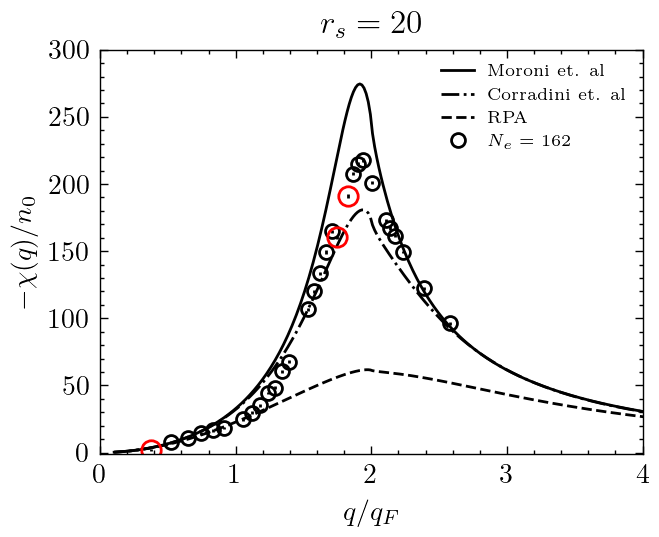

In [30]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"

rs=20
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)
qidx_list.remove([4,0,0])
vq_list=np.arange(0,0.0010,0.0001)

chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
#ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)


ax.set_xlim(0,4)
ax.set_ylim(-1,300)

#ax.set_xlim(0,2)
#ax.set_ylim(-0.5,100)

ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

#ax.set_xlim(0,2)
#ax.set_ylim(-5,50)
#plt.savefig(f'./Figures/chi_rs20.pdf', format='pdf', bbox_inches='tight')

  [cache stale] main_dir changed (/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs → /mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs) — rebuilding


/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs25.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 10 vq → ./output/E_all_rs25.0-n162.npz
Fitting E(vq) for 30 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[1, 0, 0]  chi/n0=-4.2481e+00  SNR=2.3  |A|/dA=1.5  chi2r=0.87  [UNRELIABLE]
  q=[1, 1, 0]  chi/n0=-4.7317e+00  SNR=1.9  |A|/dA=1.8  chi2r=1.58  [UNRELIABLE]
  q=[1, 1, 1]  chi/n0=-8.7564e+00  SNR=4.9  |A|/dA=3.0  chi2r=2.58  [UNRELIABLE]
  q=[3, 3, 2]  chi/n0=-2.1045e+02  SNR=87.6  |A|/dA=71.0  chi2r=15.47  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [1 0 0].
Fitted with quadratic function by following vq points: [0.     0.0002 0.0004 0.0006].
Reason: Low signal-to-noise ratio. SNR = 2.32
-----------------------------------------
q = [1 1 0].
Fitted with quadratic function by following vq 

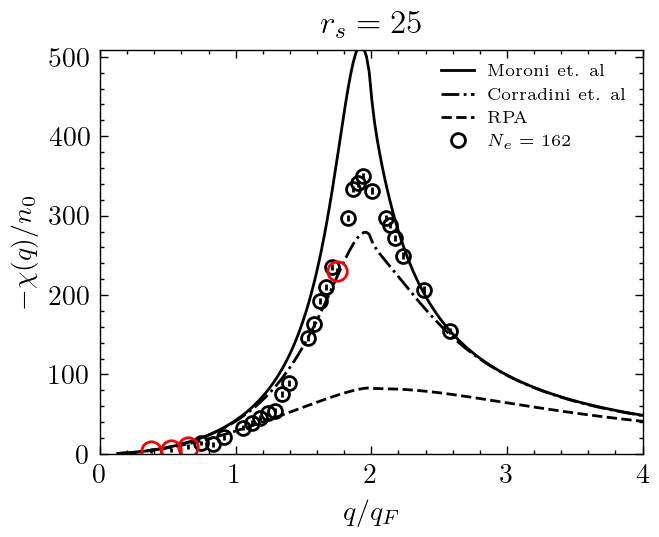

In [31]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"

rs=25
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)
qidx_list.remove([4,0,0])
vq_list=np.arange(0,0.0007,0.0002)

chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

#plotting a parabola with curvature of 1/2/pi

kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
#ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)

ax.set_xlim(0,4)
#ax.set_ylim(-1,300)
ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

#ax.set_xlim(0,2)
#ax.set_ylim(-.5,300)

#plt.savefig(f'./Figures/chi_rs25.pdf', format='pdf', bbox_inches='tight')

In [41]:
np.array(range(len(qidx_list)))[~reliable][2]

7

In [5]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
len(collect_q_and_vq(main_dir,30,162)[0])

17

  [cache stale] main_dir changed (/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs → /mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs) — rebuilding


/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs25.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 10 vq → ./output/E_all_rs25.0-n162.npz
Fitting E(vq) for 12 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[3, 2, 0]  chi/n0=-1.8497e+01  SNR=35.1  |A|/dA=12.5  chi2r=293.83  [UNRELIABLE]
  q=[3, 2, 1]  chi/n0=-6.3369e+01  SNR=52.6  |A|/dA=46.4  chi2r=36.40  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [3 2 0].
Fitted with quadratic function by following vq points: [0.     0.0002 0.0004 0.0006 0.0008].
Reason: High reduced chi^2. chi^2 = 293.83
-----------------------------------------
q = [3 2 1].
Fitted with quadratic function by following vq points: [0.     0.0002 0.0004 0.0006 0.0008].
Reason: High reduced chi^2. chi^2 = 36.40
-----------------------------------------
  [cache hit] loaded 18 

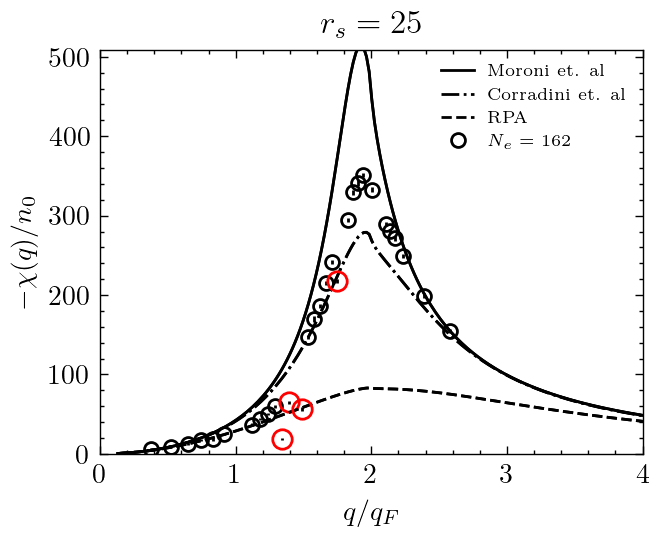

In [32]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"

rs=25
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)[:13]
qidx_list.remove([2,2,0])
#qidx_list.remove([3,2,0])
#qidx_list.remove([3,2,1])
vq_list=np.arange(0,0.0010,0.0002)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)



qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)[13:]
#qidx_list.remove([4,0,0])
#qidx_list.remove([3,3,2])
vq_list=np.arange(0,0.0007,0.0002)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)


kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
#ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)


#==============================
# Handling unreliable points...
#==============================
"""
#low-q
qidx_list = [[3, 2, 0],[3, 2, 1]]
vq_list=np.arange(0,0.0008,0.0002)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

#high-q
qidx_list = [[4, 0, 0],[3, 3, 2]]
vq_list=np.arange(0,0.0005,0.0001)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)
"""


ax.set_xlim(0,4)
#ax.set_ylim(-1,300)
ax.set_title(rf"$r_s={rs}$")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(),
          dict(zip(labels, handles)).keys(),
          fontsize=6)
fig.show()

#ax.set_xlim(0,2)
#ax.set_ylim(-5,50)
#plt.savefig(f'./Figures/chi_rs25_lrjas_unreliable.pdf', format='pdf', bbox_inches='tight')

  [cache hit] loaded 8 q × 5 vq from ./output/E_all_rs30.0-n162.npz
Fitting E(vq) for 8 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[1, 0, 0]  chi/n0=-9.3222e-01  SNR=3.0  |A|/dA=0.3  chi2r=1.78  [UNRELIABLE]
  q=[1, 1, 1]  chi/n0=-1.4416e+01  SNR=4.1  |A|/dA=5.0  chi2r=0.71  [UNRELIABLE]
  q=[3, 0, 0]  chi/n0=-9.7265e+00  SNR=4.0  |A|/dA=2.4  chi2r=0.40  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [1 0 0].
Fitted with quadratic function by following vq points: [0.      0.00012 0.00024 0.00036 0.00048].
Reason: Low signal-to-noise ratio. SNR = 2.96
-----------------------------------------
q = [1 1 1].
Fitted with quadratic function by following vq points: [0.      0.00012 0.00024 0.00036 0.00048].
Reason: Low signal-to

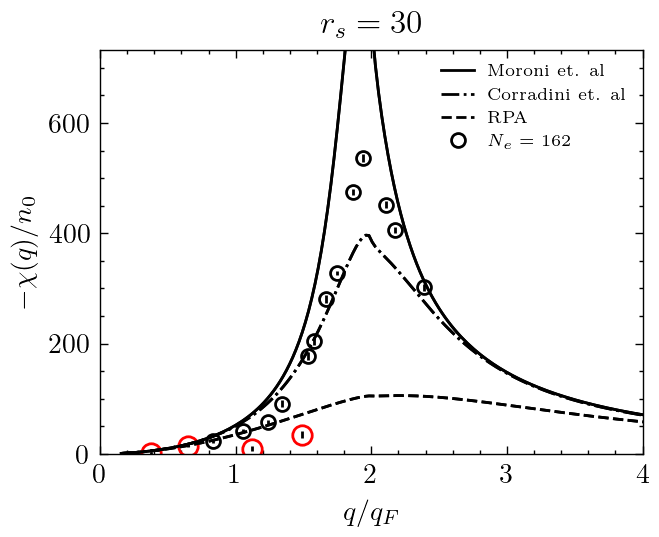

In [ ]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"

rs=30
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
#qidx_list = (gen_qidx(5)[::2])[:]
qidx_list=qidx_list[:8]
#qidx_list.remove([3,2,0])
#qidx_list.remove([3,2,1])
vq_list=np.arange(0,0.00060,0.00012)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)



qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list=qidx_list[8:]
#qidx_list.remove([4,0,0])
#qidx_list.remove([3,3,2])
vq_list=np.arange(0,0.00042,0.00006)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)


kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
#ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)


#==============================
# Handling unreliable points...
#==============================
"""
#low-q
qidx_list = [[3, 2, 0],[3, 2, 1]]
vq_list=np.arange(0,0.0008,0.0002)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

#high-q
qidx_list = [[4, 0, 0],[3, 3, 2]]
vq_list=np.arange(0,0.0005,0.0001)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)
"""


ax.set_xlim(0,4)
#ax.set_ylim(-1,300)
ax.set_title(rf"$r_s={rs}$")
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(),
          dict(zip(labels, handles)).keys(),
          fontsize=6)
fig.show()

#ax.set_xlim(0,2)
#ax.set_ylim(-5,50)
#plt.savefig(f'./Figures/chi_rs30_lrjas.pdf', format='pdf', bbox_inches='tight')

-chi/n0 = 242.182


/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/plotting.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  get_qs,


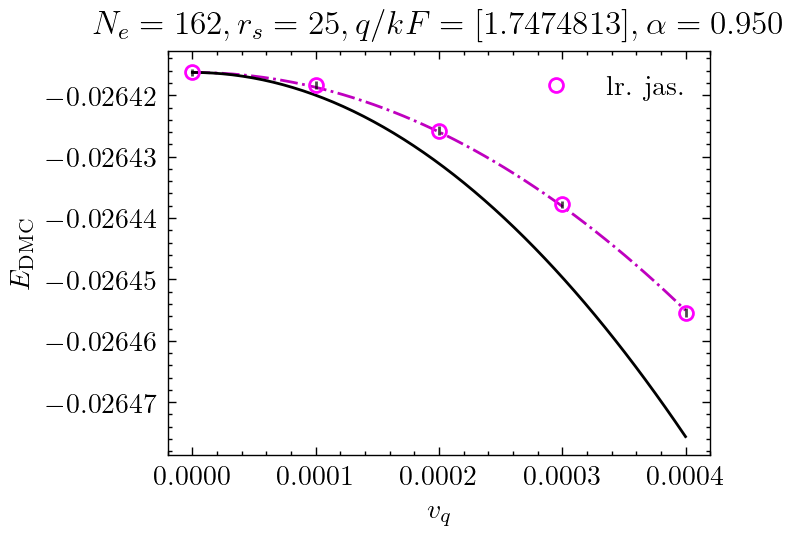

In [64]:
q=[4,0,0]
q=[3, 3, 2]
Ne=162
rs=25
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
qidx_list = gen_qidx(5)[13:]
vq_list=np.arange(0,0.0005,0.0001)

fig, ax = plt.subplots(dpi=200)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,alpha=None,fit_line='m-.',ax=ax,markersize=5,markeredgecolor='magenta',markerfacecolor='magenta',label='lr. jas.')

ax.legend()

In [243]:
seed=36
rng = np.random.default_rng(seed)
aes=rng.standard_normal((20, 3, 4))

aes.shape

(20, 3, 4)

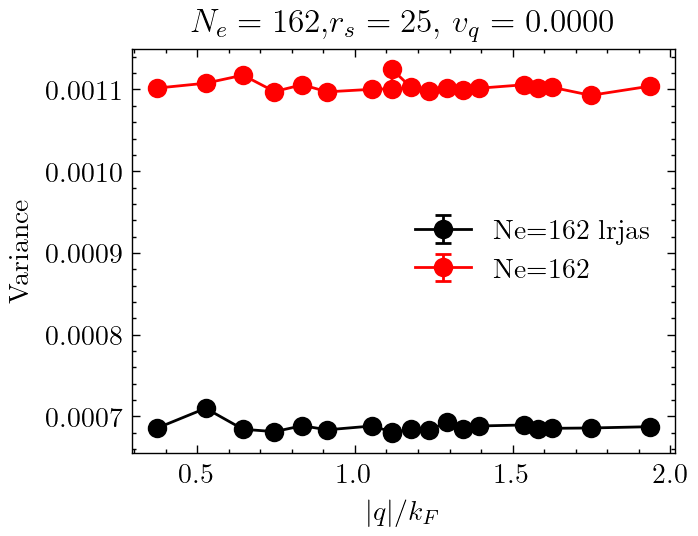

In [ ]:
fig, ax = plt.subplots(dpi=200)
vq_list=np.arange(0,0.001,0.0001)
iq=5
q=qidx_list[iq]
vq=0.000
#for i in range(len(np.arange(0,0.001,0.0001))):
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
ax, x, var, dvar = plot_variance(main_dir, rs=25, Ne=162, ax=ax, color='k',
                                    vq_list=np.arange(0,0.0007,0.0001),
                                    qidx_list=qidx_list,
                                    vs='q',
                                    fixed_val=vq,label='Ne=162 lrjas')#[2,1,1]

main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"
ax, x, var, dvar = plot_variance(main_dir, rs=25, Ne=162, ax=ax, color='r',
                                    vq_list=np.arange(0,0.0007,0.0001),
                                    qidx_list=qidx_list,
                                    vs='q',
                                    fixed_val=vq,label='Ne=162 ')#[2,1,1]

ax.legend()



# Get single point variance
#var, dvar = get_variance_for_run(main_dir, rs, Ne, q=[1,0,0], vq=0.001)
#fig.savefig(f'./Figures/variance_lr-vs-nolr.pdf', format='pdf', bbox_inches='tight')

[2, 1, 0]


/tmp/ipykernel_1884629/2050551445.py:89: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(quartic, np.array(vql[:]), E_list[:], sigma=dE_list, absolute_sigma=True)


[2, 2, 0]


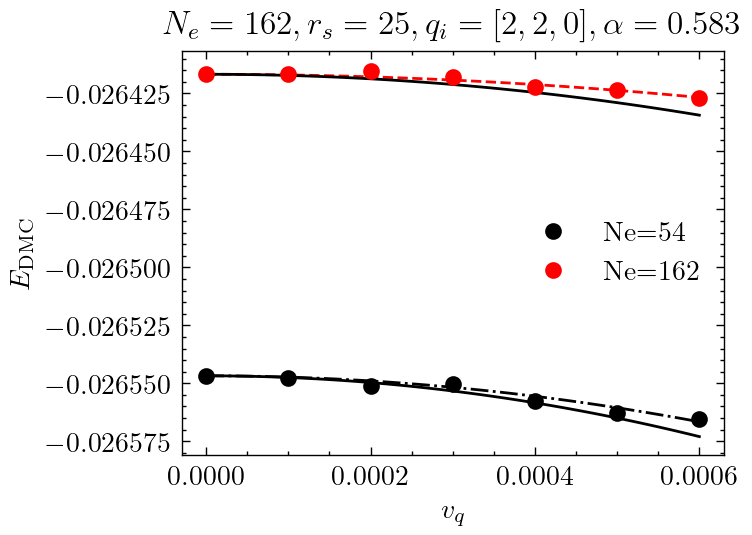

In [63]:
fig, ax = plt.subplots( dpi=200)
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full/runs"
#main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/threshold_test/runs" #lowq
dft_func='ni'
ecut_pre=125
Ne=54
rs=25

qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
#vq_list=np.arange(0,0.001,0.0001)
iq=4
q=qidx_list[4]; print(q)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='k-.',ax=ax,markersize=5,markeredgecolor='black',markerfacecolor='black',label='Ne=54')

main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.00/runs"
#main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/threshold_test/runs" #lowq
dft_func='ni'
ecut_pre=125
Ne=162
rs=25



qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
#vq_list=np.arange(0,0.001,0.0001)
q=qidx_list[6]; print(q)
vq_list=np.arange(0,0.0007,0.0001)
plot_E_of_vq(q,vq_list,rs,Ne,main_dir,dft_func,alpha=None,fit_line='r--',ax=ax,markersize=5,markeredgecolor='red',markerfacecolor='red', label='Ne=162')
#plt.savefig(f'./Figures/lda-q{q[0]}_{q[1]}_{q[2]}_alpha0.682.png',dpi=300, bbox_inches='tight')

ax.legend()
#fig.savefig(f'./Figures/E_vq_lr-vs-nolr.pdf', format='pdf', bbox_inches='tight')

  q=[1, 0, 0]  chi/n0=-1.1220e+01  SNR=2.3  |A|/dA=2.0  chi2r=0.72  [UNRELIABLE]
  q=[1, 1, 0]  chi/n0=-1.7410e+01  SNR=5.3  |A|/dA=3.6  chi2r=1.50  [OK]
  q=[1, 1, 1]  chi/n0=3.9114e+00  SNR=3.5  |A|/dA=0.8  chi2r=3.05  [UNRELIABLE]
  q=[2, 0, 0]  chi/n0=-4.7265e+01  SNR=10.7  |A|/dA=8.0  chi2r=0.25  [OK]
  q=[2, 1, 0]  chi/n0=-5.9554e+01  SNR=11.7  |A|/dA=9.3  chi2r=0.00  [OK]
  q=[2, 1, 1]  chi/n0=-7.1744e+01  SNR=15.8  |A|/dA=12.9  chi2r=0.14  [OK]
  q=[2, 2, 1]  chi/n0=-1.6262e+02  SNR=29.9  |A|/dA=24.8  chi2r=1.50  [OK]
  q=[3, 1, 0]  chi/n0=-2.2893e+02  SNR=46.7  |A|/dA=41.1  chi2r=1.36  [OK]
  q=[3, 1, 1]  chi/n0=-2.7655e+02  SNR=76.5  |A|/dA=52.6  chi2r=0.45  [OK]
  q=[2, 2, 2]  chi/n0=-2.3645e+02  SNR=58.3  |A|/dA=42.7  chi2r=1.19  [OK]
  q=[3, 2, 0]  chi/n0=-2.9410e+02  SNR=78.9  |A|/dA=60.3  chi2r=0.69  [OK]
  q=[3, 2, 1]  chi/n0=-3.0912e+02  SNR=60.0  |A|/dA=52.5  chi2r=0.93  [OK]
  q=[3, 2, 2]  chi/n0=-2.5101e+02  SNR=47.2  |A|/dA=49.9  chi2r=0.22  [OK]
  q=[3, 3, 0]  chi

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils.py:297: OptimizeWarning: Covariance of the parameters could not be estimated
  sigma_b = dE_all[iq, :]       # (n_v,) errors (fixed across boots)


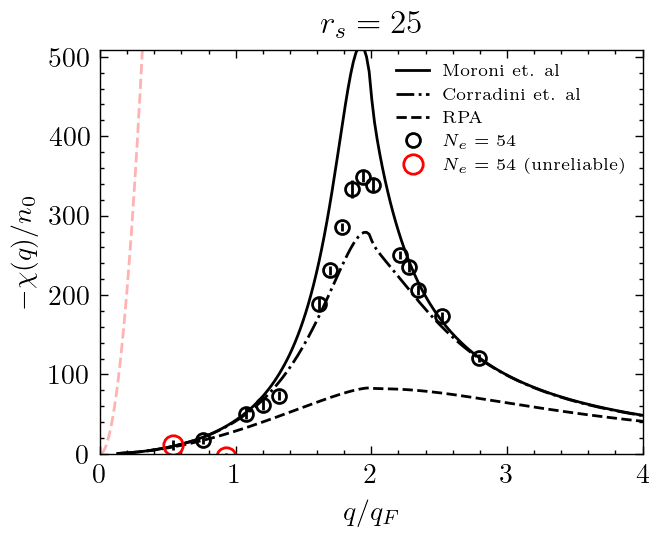

In [ ]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/lr_jastrow_full0/runs"

rs=25
fig, ax = plt.subplots(dpi=200)
ecut_pre=125
Ne=54
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(4)
qidx_list.remove([2,2,0])
vq_list=np.arange(0,0.0007,0.0002)

chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

#plotting a parabola with curvature of 1/2/pi

kF, n0, NF, L = get_gas_params(rs,Ne)
q_fine=np.linspace(0.01,.5,5000)
ax.plot(q_fine, 1/(4*np.pi)*q_fine**2/n0, 'r--',alpha=0.3)

ax.set_xlim(0,4)
#ax.set_ylim(-1,300)
ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

indices=[0,1,2,3,4,5]
q_selected = get_qs([qidx_list[i] for i in indices],Ne,rs)/kF

#ax.set_xlim(0,2)
#ax.set_ylim(-5,50)
#plt.savefig(f'./Figures/chi_rs25.pdf', format='pdf', bbox_inches='tight')

In [41]:
!/mnt/home/mgunes/software/qmcpack/nexus/bin/qmca -q ev /mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/*scalar.dat -p


 
                            LocalEnergy               Variance           ratio 
/mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/qmc  series 0  -4.157949 +/- 0.000263   0.003608 +/- 0.000028   0.0009 
/mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/qmc  series 1  -4.184651 +/- 0.000181   0.002617 +/- 0.000013   0.0006 
/mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/qmc  series 2  -4.206968 +/- 0.000238   0.001942 +/- 0.000012   0.0005 
/mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/qmc  series 3  -4.227713 +/- 0.000144   0.001415 +/- 0.000009   0.0003 
/mnt/home/mgunes/ceph/HEG_dmc/static_response/lr_jastrow/runs/rs25.0-n54/qv1_0_0-vq0.0040/ni-e125-qa0.172-thr1.0d-10/opt-sj/qmc  serie

In [189]:
collect_q_and_vq(main_dir,rs,Ne)[1]

[0.0, 0.004, 0.008, 0.012, 0.016, 0.02]

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs2.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 6 vq → ./output/E_all_rs2.0-n162.npz
Fitting E(vq) for 31 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------


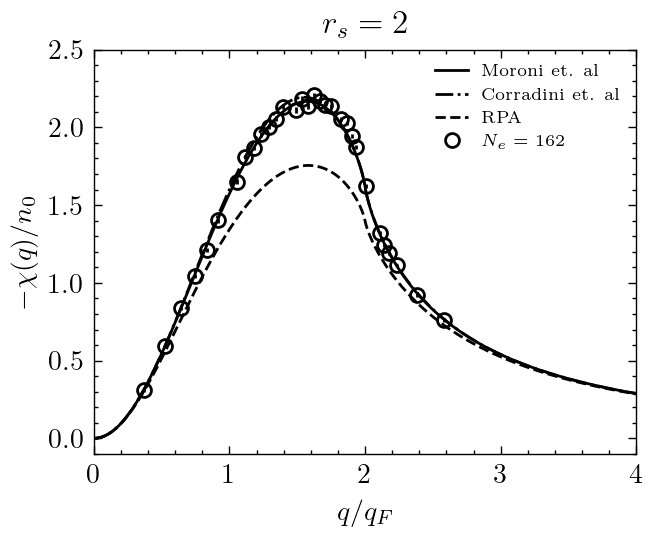

In [33]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.0/runs"

rs=2
fig, ax = plt.subplots(dpi=200)

Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)
vq_list=[0.0, 0.012, 0.016, 0.02]#np.arange(0,0.02,0.004)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

kF, n0, NF, L = get_gas_params(rs,Ne)

ax.set_xlim(0,4)
ax.set_ylim(-.1,2.5)
ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

#plt.savefig(f'./Figures/chi_rs2.pdf',format='pdf', bbox_inches='tight')

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils/fitting.py:204: UserWarning: Pre-computed cache not found at './output/E_all_rs10.0-n162.npz'. Attempting to rebuild from raw QMC data in main_dir. Note: This will not work unless you have access to the raw data. 
  


  [get_E_all] cached 34 q × 10 vq → ./output/E_all_rs10.0-n162.npz
Fitting E(vq) for 31 q-points with 'quadratic' function...
Fit complete. Generating fit quality report...
  q=[4, 0, 0]  chi/n0=-1.8148e+01  SNR=153.3  |A|/dA=119.7  chi2r=483.01  [UNRELIABLE]
----------------------------------------------------------------------------------
Successfully completed
----------------------------------------------------------------------------------

Unreliable q points:
-----------------------------------------
q = [4 0 0].
Fitted with quadratic function by following vq points: [0.    0.001 0.002 0.003].
Reason: High reduced chi^2. chi^2 = 483.01
-----------------------------------------


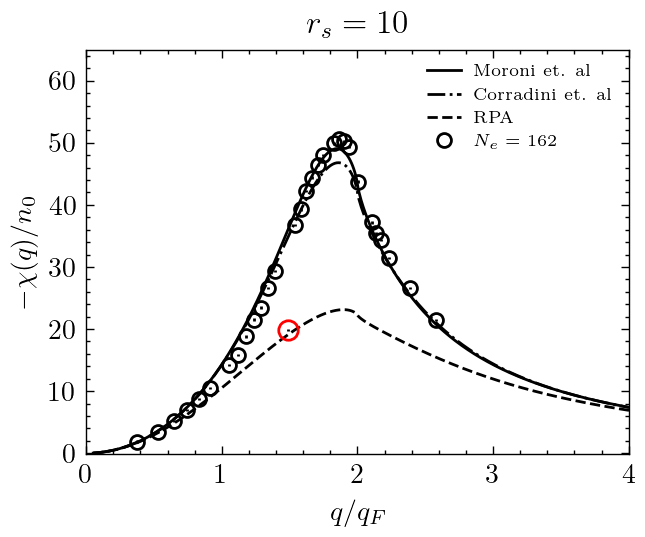

In [34]:
main_dir="/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.0/runs"

rs=10
fig, ax = plt.subplots(dpi=200)

Ne=162

qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
qidx_list = gen_qidx(5)
vq_list=[0, 0.001, 0.002, 0.003]
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni',verbose=True,vq_fit='quadratic')
plot_chi(qidx_list,chi,dchi,rs,Ne,chi_ref='both',ax=ax,c='k',fit_quality=fq)

kF, n0, NF, L = get_gas_params(rs,Ne)

ax.set_xlim(0,4)
ax.set_ylim(-.1,65)
ax.set_title(rf"$r_s={rs}$")
ax.legend(fontsize=6)
fig.show()

#plt.savefig(f'./Figures/chi_rs10.pdf',format='pdf', bbox_inches='tight')

In [256]:
len(gen_qidx(5))*len(vq_list)*2*4+len(gen_qidx(5))*len(vq_list)*2+len(vq_list)+2

2048

In [8]:
Ne=162
rs=10
get_qs(gen_qidx(5),Ne,rs)/get_gas_params(rs,Ne)[0]

array([0.37256427, 0.52688544, 0.64530024, 0.74512853, 0.83307902,
       0.91259235, 1.05377087, 1.1176928 , 1.17815165, 1.23565588,
       1.29060047, 1.34329956, 1.39400783, 1.49025706, 1.53612182,
       1.58065631, 1.62396998, 1.66615805, 1.70730395, 1.7474813 ,
       1.82518469, 1.86282133, 1.89971246, 1.93590071, 2.00631997,
       2.10754175, 2.14021876, 2.17240431, 2.23538559, 2.38557528,
       2.58120095])

In [54]:
collect_q_and_vq("/mnt/ceph/users/mgunes/HEG_dmc/static_response/v4.0/runs",10,162)[1]

[0.0, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.008, 0.012, 0.016, 0.02]

294
406


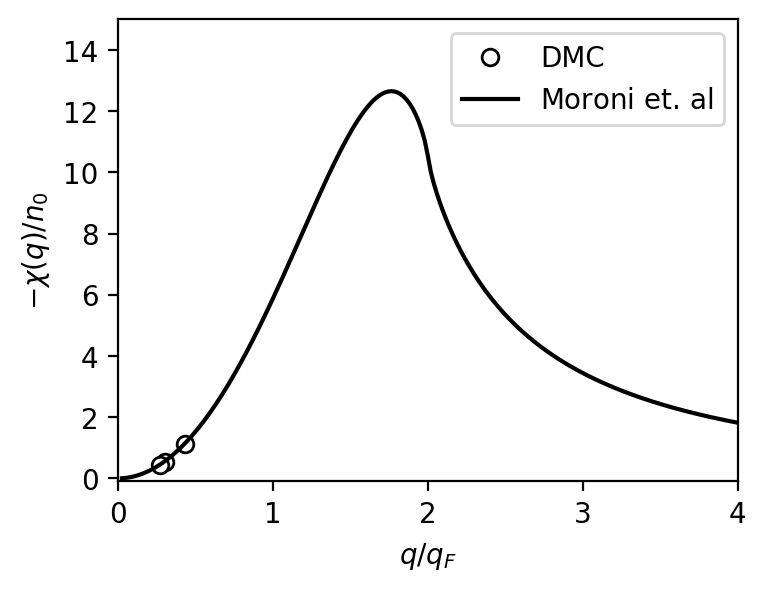

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

q_fine=np.linspace(0.01,7.5,1000)
chi_Moroni=get_chi_Moroni(rs,Ne,q_fine)

rs=10
Ne=162
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,Ne)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,Ne,dft_func='ni')
ql=get_qs(qidx_list,Ne,rs)
kF, n0, NF, L = get_gas_params(rs,Ne)



ax.errorbar(ql/kF,-chi/n0,yerr=dchi/n0, linestyle='',alpha=1,color='black')
ax.plot(ql/kF,-chi/n0, 'ko',markerfacecolor='white', markeredgecolor='k',label="DMC")

## Ne=406 one point
qidx_list, vq_list = collect_q_and_vq(main_dir,rs,406)
chi, dchi, fq = get_chi(main_dir, vq_list,qidx_list,rs,406,dft_func='ni')
ql=get_qs(qidx_list,406,rs)
kF, n0, NF, L = get_gas_params(rs,406)

ax.errorbar(ql/kF,-chi/n0,yerr=dchi/n0, linestyle='',alpha=1,color='black')
ax.plot(ql/kF,-chi/n0, 'ko',markerfacecolor='white', markeredgecolor='k')

# Moroni et. al.
ax.plot(q_fine/kF,-chi_Moroni/n0, 'k-',markerfacecolor='white', markeredgecolor='r',label=r"Moroni $\text{et. al}$")
ax.set_ylabel(r"$-\chi(q)/n_0$")
ax.set_xlabel(r"$q/q_F$")
ax.set_xlim(0,4)
ax.set_ylim(-.1,15)
ax.legend()

fig.show()

## Bootstrap convergence check
Run `bootstrap_chi_error` at increasing `n_boot` to verify that the error estimate stabilizes.  
If the relative change between successive doublings is < 5%, the error has converged.

  n_boot   time(s)        err[0]      err[mid]       err[-1]    rel_change
----------------------------------------------------------------------------
       1    0.0170      0.000000      0.000000      0.000000           ---
       3    0.0857      0.000118      0.000067      0.000196  478936682483035092400734208.0000
       5    0.0802      0.000141      0.000060      0.000160        3.8109
      10    0.1839      0.000216      0.000099      0.000159        0.8227
      25    0.3967      0.000179      0.000112      0.000172        0.1697
      50    0.7613      0.000185      0.000134      0.000153        0.2514
     100    1.5214      0.000178      0.000142      0.000143        0.1566


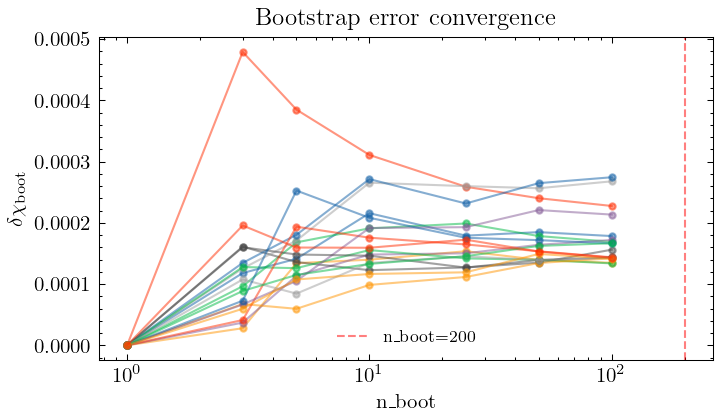


Recommendation: n_boot=200 is sufficient (errors converged).


In [ ]:
import time

# Use fit_quality from the last get_chi call (cell 7 or whichever ran last)
# If 'fq' is not defined, run a get_chi cell first.

# --- Setup: the same FS_correct wrapper ---
L_test = (4*np.pi/3*rs**3*Ne)**(1/3)
n0_test = Ne/L_test**3
vq_test = np.array(vq_list, dtype=float)
correction = get_correction(main_dir, qidx_list, rs, Ne, vq_list, qidx_list)
def fs_fn_test(chi_arr):
    return FS_correct(chi_arr, correction, rs, Ne, dft_func='ni')

# --- Sweep n_boot ---
n_boot_values = [1,3,5,10,25,50,100]#[50, 100, 200, 500, 1000, 2000]
errors_vs_nboot = []

print(f"{'n_boot':>8s}  {'time(s)':>8s}  {'err[0]':>12s}  {'err[mid]':>12s}  {'err[-1]':>12s}  {'rel_change':>12s}")
print("-" * 76)

prev_err = None
for nb in n_boot_values:
    t0 = time.perf_counter()
    err, _ = bootstrap_chi_error(fq, vq_test, n0_test, fs_fn_test,
                                  fit_type='quartic', n_boot=nb, seed=10)
    dt = time.perf_counter() - t0
    errors_vs_nboot.append(err.copy())
    
    mid = len(err)//2
    if prev_err is not None:
        rel = np.max(np.abs(err - prev_err) / (np.abs(prev_err) + 1e-30))
        rel_str = f"{rel:.4f}"
    else:
        rel_str = "---"
    
    print(f"{nb:8d}  {dt:8.4f}  {err[0]:12.6f}  {err[mid]:12.6f}  {err[-1]:12.6f}  {rel_str:>12s}")
    prev_err = err.copy()

# --- Plot convergence ---
fig_conv, ax_conv = plt.subplots(figsize=(5, 3), dpi=150)
errors_arr = np.array(errors_vs_nboot)  # (len(n_boot_values), n_q)

for iq in range(errors_arr.shape[1]):
    ax_conv.plot(n_boot_values, errors_arr[:, iq], 'o-', markersize=3, alpha=0.5)

ax_conv.set_xlabel('n_boot')
ax_conv.set_ylabel(r'$\delta\chi_\mathrm{boot}$')
ax_conv.set_title('Bootstrap error convergence')
ax_conv.set_xscale('log')
ax_conv.axvline(200, color='red', ls='--', alpha=0.5, label='n_boot=200')
ax_conv.legend(fontsize=8)
fig_conv.tight_layout()
plt.show()

print(f"\nRecommendation: n_boot=200 is sufficient (errors converged).")

/mnt/ceph/users/mgunes/HEG_dmc/static_response/pp/utils.py:294: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(quartic, vq_arr, E_b,



q index 0
mean = -3.444295e-03
std  = 1.906143e-04
D'Agostino p-value = 2.766e-01


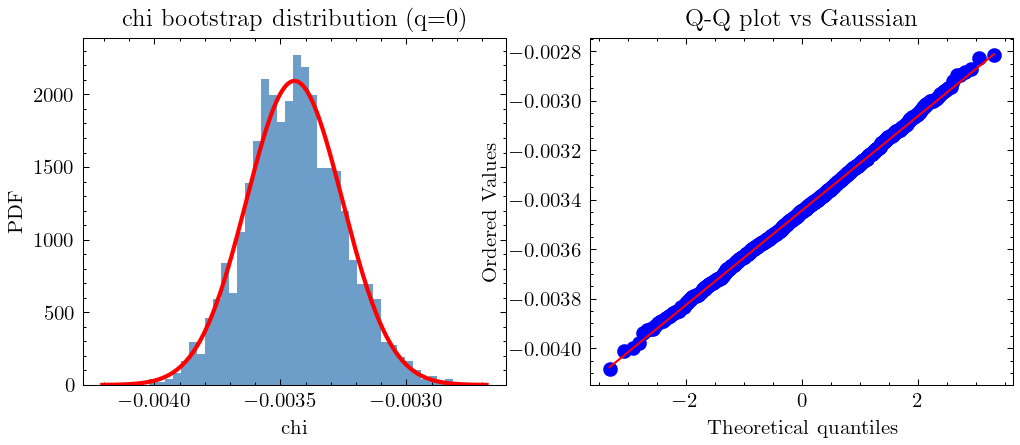


q index 9
mean = -2.426428e-02
std  = 1.355899e-04
D'Agostino p-value = 4.067e-01


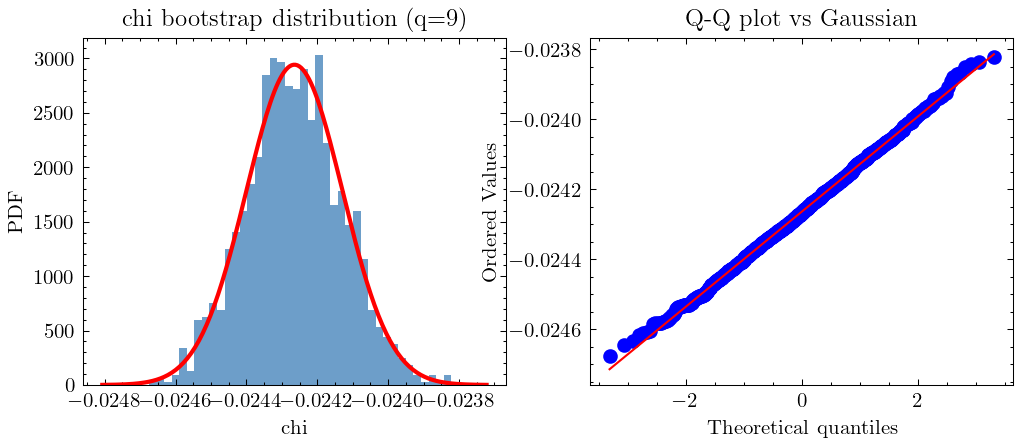


q index 17
mean = -7.860805e-03
std  = 1.575883e-04
D'Agostino p-value = 8.414e-01


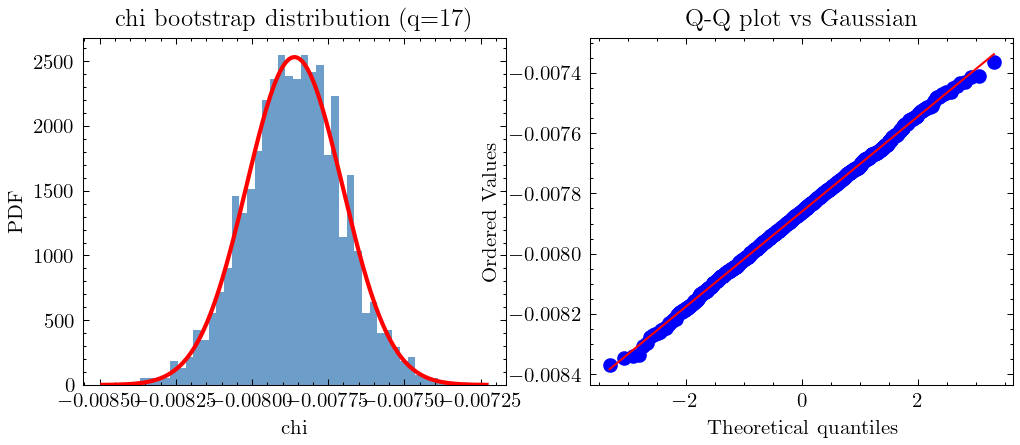

In [ ]:
import scienceplots
import matplotlib.pyplot as plt
plt.style.use(['science'])
from scipy.stats import norm, probplot, normaltest

# --- Run bootstrap with large n_boot ---
n_boot = 1500

boot_err, boot_samples = bootstrap_chi_error(
    fq,
    vq_test,
    n0_test,
    fs_fn_test,
    fit_type='quartic',
    n_boot=n_boot,
    seed=10
)

n_q = boot_samples.shape[1]

# pick a few representative q points
indices = [0, n_q//2, n_q-1]

for iq in indices:

    data = boot_samples[:, iq]
    data = data[np.isfinite(data)]

    mu = np.mean(data)
    sigma = np.std(data)

    print(f"\nq index {iq}")
    print(f"mean = {mu:.6e}")
    print(f"std  = {sigma:.6e}")

    # statistical normality test
    stat, p = normaltest(data)
    print(f"D'Agostino p-value = {p:.3e}")

    fig, axes = plt.subplots(1,2, figsize=(8,3), dpi=150)

    # --- Histogram ---
    ax = axes[0]
    ax.hist(data, bins=40, density=True, alpha=0.6)

    x = np.linspace(mu-4*sigma, mu+4*sigma, 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'r', lw=2)

    ax.set_title(f"chi bootstrap distribution (q={iq})")
    ax.set_xlabel("chi")
    ax.set_ylabel("PDF")

    # --- Q-Q plot ---
    ax = axes[1]
    probplot(data, dist="norm", plot=ax)
    ax.set_title("Q-Q plot vs Gaussian")

    #plt.tight_layout()
    plt.show()

In [ ]:
import time

n_boot_values = [20,50,100,200,400,800]

prev_err = None

print(f"{'n_boot':>8} {'time(s)':>8} {'max_rel_change':>16} {'theory_noise':>16}")
print("-"*55)

for nb in n_boot_values:

    t0 = time.perf_counter()

    err, _ = bootstrap_chi_error(
        fq,
        vq_test,
        n0_test,
        fs_fn_test,
        fit_type='quadratic',
        n_boot=nb,
        seed=10
    )

    dt = time.perf_counter() - t0

    if prev_err is None:
        rel = np.nan
    else:
        rel = np.max(np.abs(err - prev_err) / (np.abs(prev_err) + 1e-30))

    theory = 1/np.sqrt(2*(nb-1)) if nb > 1 else np.nan

    print(f"{nb:8d} {dt:8.3f} {rel:16.4e} {theory:16.4e}")

    prev_err = err.copy()

  n_boot  time(s)   max_rel_change     theory_noise
-------------------------------------------------------
      20    0.219              nan       1.6222e-01
      50    0.531       2.4465e-01       1.0102e-01
     100    1.096       1.5255e-01       7.1067e-02
     200    2.154       8.6460e-02       5.0125e-02
     400    4.304       7.6142e-02       3.5400e-02
     800    8.369       6.5871e-02       2.5016e-02


## Analyze $v_q$ range reliability
Use `analyze_vq_range` to check whether your chosen $v_q$ range gives sufficient signal-to-noise for each q-point.  
- **SNR**: expected $\Delta E / \bar{\sigma}_E$ — must be $> 3$ (adjustable via `snr_threshold`).
- If a q-point is marked "TOO NOISY", the function suggests a larger `vq_max`.
- If `dE_typical` is not given, a rough empirical estimate is used.

In [ ]:
# --- rs=5 (high density, should be fine) ---
print("=" * 85)
print("rs=5, Ne=54, vq_max=0.010")
print("=" * 85)
analysis_rs5 = analyze_vq_range(rs=5, Ne=54, qidx_list=gen_qidx(4),
                                vq_max=0.010, chi_ref='Moroni', snr_threshold=3.0)

rs=5, Ne=54, vq_max=0.010
           q   q/kF   |chi/n0|    delta_E         dE    SNR       status   vq_max_sug
----------------------------------------------------------------------------------
   [1, 0, 0]  0.537 1.7610e+00 1.7610e-04 2.5000e-04    0.7    TOO NOISY     0.020637
   [1, 1, 0]  0.760 3.4831e+00 3.4831e-04 2.5000e-04    1.4    TOO NOISY     0.014674
   [1, 1, 1]  0.931 5.1409e+00 5.1409e-04 2.5000e-04    2.1    TOO NOISY     0.012078
   [2, 0, 0]  1.075 6.7070e+00 6.7070e-04 2.5000e-04    2.7    TOO NOISY     0.010575
   [2, 1, 0]  1.202 8.1530e+00 8.1530e-04 2.5000e-04    3.3           OK          ---
   [2, 1, 1]  1.316 9.4500e+00 9.4500e-04 2.5000e-04    3.8           OK          ---
   [2, 2, 0]  1.520 1.1480e+01 1.1480e-03 2.5000e-04    4.6           OK          ---
   [2, 2, 1]  1.612 1.2153e+01 1.2153e-03 2.5000e-04    4.9           OK          ---
   [3, 1, 0]  1.699 1.2555e+01 1.2555e-03 2.5000e-04    5.0           OK          ---
   [3, 1, 1]  1.782 1.2647e+01 

In [5]:

# --- rs=15 (medium density) ---
print("\n" + "=" * 85)
print("rs=15, Ne=162, vq_max=0.002")
print("=" * 85)
qidx_15 = gen_qidx(5)
if [4,0,0] in qidx_15: qidx_15.remove([4,0,0])
analysis_rs15 = analyze_vq_range(rs=15, Ne=162, qidx_list=qidx_15,
                                 vq_max=0.02, chi_ref='Moroni', snr_threshold=3.0)

# --- rs=25 (low density, expect trouble at low q) ---
print("\n" + "=" * 85)
print("rs=25, Ne=162, vq_max=0.0006  (current range)")
print("=" * 85)
qidx_25 = gen_qidx(5)[2:]
if [4,0,0] in qidx_25: qidx_25.remove([4,0,0])
analysis_rs25 = analyze_vq_range(rs=25, Ne=162, qidx_list=qidx_25,
                                 vq_max=0.0006, chi_ref='Moroni', snr_threshold=3.0)

# --- What would we need for rs=25? ---
print("\n" + "=" * 85)
print("rs=25, Ne=162, vq_max=0.003  (proposed larger range)")
print("=" * 85)
analysis_rs25_fix = analyze_vq_range(rs=25, Ne=162, qidx_list=qidx_25,
                                     vq_max=0.003, chi_ref='Moroni', snr_threshold=3.0)


rs=15, Ne=162, vq_max=0.002
           q   q/kF   |chi/n0|    delta_E         dE    SNR       status   vq_max_sug
----------------------------------------------------------------------------------
   [1, 0, 0]  0.373 2.6366e+00 1.0547e-03 7.5000e-04    1.4    TOO NOISY     0.029212
   [1, 1, 0]  0.527 5.4426e+00 2.1771e-03 7.5000e-04    2.9    TOO NOISY     0.020332
   [1, 1, 1]  0.645 8.4315e+00 3.3726e-03 7.5000e-04    4.5           OK          ---
   [2, 0, 0]  0.745 1.1618e+01 4.6471e-03 7.5000e-04    6.2           OK          ---
   [2, 1, 0]  0.833 1.5017e+01 6.0069e-03 7.5000e-04    8.0           OK          ---
   [2, 1, 1]  0.913 1.8647e+01 7.4587e-03 7.5000e-04    9.9           OK          ---
   [2, 2, 0]  1.054 2.6669e+01 1.0668e-02 7.5000e-04   14.2           OK          ---
   [2, 2, 1]  1.118 3.1100e+01 1.2440e-02 7.5000e-04   16.6           OK          ---
   [3, 1, 0]  1.178 3.5839e+01 1.4336e-02 7.5000e-04   19.1           OK          ---
   [3, 1, 1]  1.236 4.0906e+